In [45]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/archive (2)/ai-impact-jobs-layoff-risk-dataset.csv")

In [46]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [47]:
df

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium


In [48]:
df['Layoff_Risk'].value_counts()

,count
Layoff_Risk,
High,6797
Low,6602
Medium,6601


In [49]:
X = df.drop('Layoff_Risk', axis=1)
y = df['Layoff_Risk']
X = pd.get_dummies(X, drop_first=True)

In [50]:
from xgboost import XGBClassifier

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Layoff_Risk'])

X = df.drop('Layoff_Risk', axis=1)

X = pd.get_dummies(X, drop_first=True)

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [53]:
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9148333333333334

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2039
           1       0.95      0.92      0.93      1981
           2       0.86      0.89      0.87      1980

    accuracy                           0.91      6000
   macro avg       0.92      0.91      0.92      6000
weighted avg       0.92      0.91      0.92      6000



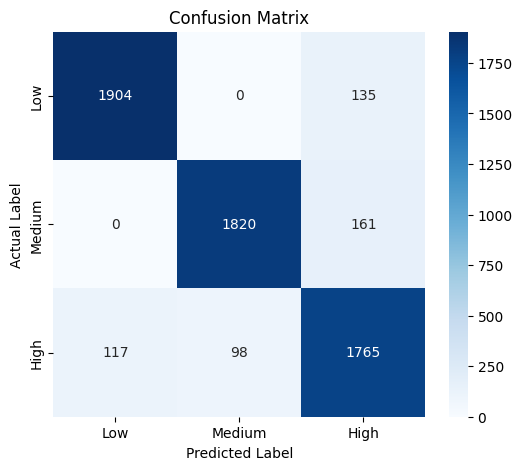

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,      # show numbers
    fmt='d',         # integer format
    cmap='Blues',    # color scheme
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [56]:
import joblib
from google.colab import files

joblib.dump(model, 'xgboost_model.pkl')
files.download('xgboost_model.pkl')

joblib.dump(le, 'label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['label_encoder.pkl']